## 🧠 What is Fast R-CNN?

**Fast R-CNN** is a **single-stage, end-to-end object detection algorithm** proposed by **Ross Girshick in 2015**, that significantly improves on R-CNN by:

* Eliminating redundant computations,
* Unifying training into one pipeline,
* Increasing speed and accuracy.

---

## 🧬 Core Motivation

R-CNN had 3 big problems:

1. **Slow Inference**: CNN was run separately on each region proposal (\~2000 per image).
2. **Multi-stage Training**: CNN fine-tuning, SVMs, and regressors were trained separately.
3. **Storage & Memory-Heavy**: Feature maps for every region were stored on disk.

➡️ **Fast R-CNN** solves all of these using the **RoI Pooling layer**, enabling CNN computation sharing and end-to-end training.

---

## 🏗️ Detailed Architecture and Workflow

Let’s go step-by-step:

---

### 🔹 Step 1: Input Image

* You input the **entire image**, without cropping or resizing individual region proposals (as R-CNN did).

---

### 🔹 Step 2: Shared Convolutional Layers

* The full image is passed **once** through a **Convolutional Neural Network** (e.g., VGG16, ResNet).
* Output: A **feature map** for the entire image (e.g., 512×50×37 for VGG16 on a 600×1000 image).

💡 This is the **key optimization** over R-CNN — CNN computation is **shared across all RoIs**, instead of repeating for each region.

---

### 🔹 Step 3: Region Proposals (RoIs)

* Uses **Selective Search** (same as R-CNN) to generate \~2000 region proposals.
* Each RoI is a bounding box (`(x1, y1, x2, y2)` coordinates) in the original image.

---

### 🔹 Step 4: RoI Pooling Layer (Key Innovation)

Problem:

* CNN feature maps are fixed size, but region proposals vary in size.

Solution:

* **RoI Pooling** extracts a **fixed-size (e.g., 7×7)** feature map from each region proposal on the shared feature map.

How it works:

* Takes a region from the feature map.
* Divides it into fixed-size bins (say, 7×7).
* In each bin, applies **max pooling** to get one value.
* Result: A 7×7×depth feature vector for each RoI.

---

### 🔹 Step 5: Fully Connected Layers

* The 7×7 pooled features for each RoI are passed through **two fully connected (FC) layers**.

---

### 🔹 Step 6: Two Output Heads

Fast R-CNN uses a **multi-task head** for each RoI:

1. **Classification Head (Softmax Layer)**:

   * Outputs class probabilities.
   * If there are `C` object classes, it outputs **C+1 scores** (including background).

2. **Bounding Box Regression Head**:

   * For each class, predicts 4 bounding box offsets (`tx, ty, tw, th`).
   * Total outputs: **4 × C**.

So for **each RoI**, Fast R-CNN outputs:

* A vector of class probabilities (`p0, p1, ..., pC`)
* A set of bounding box refinements (per class)

---

## 📐 Mathematical Formulation

### 1. **Classification Loss (Softmax)**

Given:

* Ground truth class label: $u$
* Predicted class probabilities: $p = (p_0, ..., p_C)$

Cross-entropy loss:

$$
L_{\text{cls}} = -\log(p_u)
$$

---

### 2. **Bounding Box Regression Loss (Smooth L1)**

Let:

* Ground truth box = $G = (x_g, y_g, w_g, h_g)$
* Proposal box = $P = (x_p, y_p, w_p, h_p)$

Target transformations:

$$
t_x = \frac{x_g - x_p}{w_p}, \quad
t_y = \frac{y_g - y_p}{h_p}, \quad
t_w = \log\left(\frac{w_g}{w_p}\right), \quad
t_h = \log\left(\frac{h_g}{h_p}\right)
$$

Predicted = $(\hat{t}_x, \hat{t}_y, \hat{t}_w, \hat{t}_h)$

Loss per coordinate (Smooth L1):

$$
L_{\text{reg}} = \sum_{i \in \{x,y,w,h\}} \text{Smooth}_{L1}(t_i - \hat{t}_i)
$$

Where:

$$
\text{Smooth}_{L1}(x) =
\begin{cases}
0.5x^2 & \text{if } |x| < 1 \\
|x| - 0.5 & \text{otherwise}
\end{cases}
$$

---

### 3. **Multi-Task Loss**

Total loss for each RoI:

$$
L = L_{\text{cls}} + \lambda [u \geq 1] L_{\text{reg}}
$$

* $[u \geq 1]$ is an indicator function that enables bbox regression only for object classes (not background).
* λ is typically set to 1.

---

## 🧪 Training Fast R-CNN

* All parameters (CNN, classifier, and regressor) are **trained jointly** using SGD.
* **End-to-end training** using backpropagation.
* Mini-batch: \~128 RoIs per image.

---

## 🟢 Advantages Over R-CNN

| Feature            | R-CNN          | Fast R-CNN     |
| ------------------ | -------------- | -------------- |
| CNN Forward Passes | 2000 per image | 1 per image    |
| Training Pipeline  | 3 stages       | Single-stage   |
| Training Time      | Long           | Short          |
| Disk Usage         | High           | Minimal        |
| Accuracy (mAP)     | Lower          | Higher         |
| Speed (inference)  | Very slow      | 10–100× faster |

---

## ❌ Limitations

1. **Still uses Selective Search**:

   * Not learnable
   * Slow (\~2s per image)
2. **Not real-time** yet

➡️ These were addressed by **Faster R-CNN**, which uses a learnable **Region Proposal Network (RPN)**.

---

## 📊 Performance (as reported in the paper)

* **Pascal VOC 2007**:

  * R-CNN (mAP): \~66.0%
  * Fast R-CNN (mAP): \~70.0%
* **Training Time**:

  * 9× faster than R-CNN
* **Inference Speed**:

  * Up to **213× faster** than R-CNN with VGG16

---

## 🧠 Summary Table

| Component                 | Fast R-CNN                       |
| ------------------------- | -------------------------------- |
| Input                     | Full image                       |
| Feature Extraction        | CNN over full image              |
| Region Proposals          | Selective Search                 |
| Region Feature Extraction | RoI Pooling                      |
| Output                    | Class + Bounding Box             |
| Training                  | End-to-End                       |
| Loss Function             | Multi-task (Softmax + Smooth L1) |

---

## 🔁 Evolution Timeline

```
R-CNN (2014) → Fast R-CNN (2015) → Faster R-CNN (2015) → Mask R-CNN (2017)
```

---


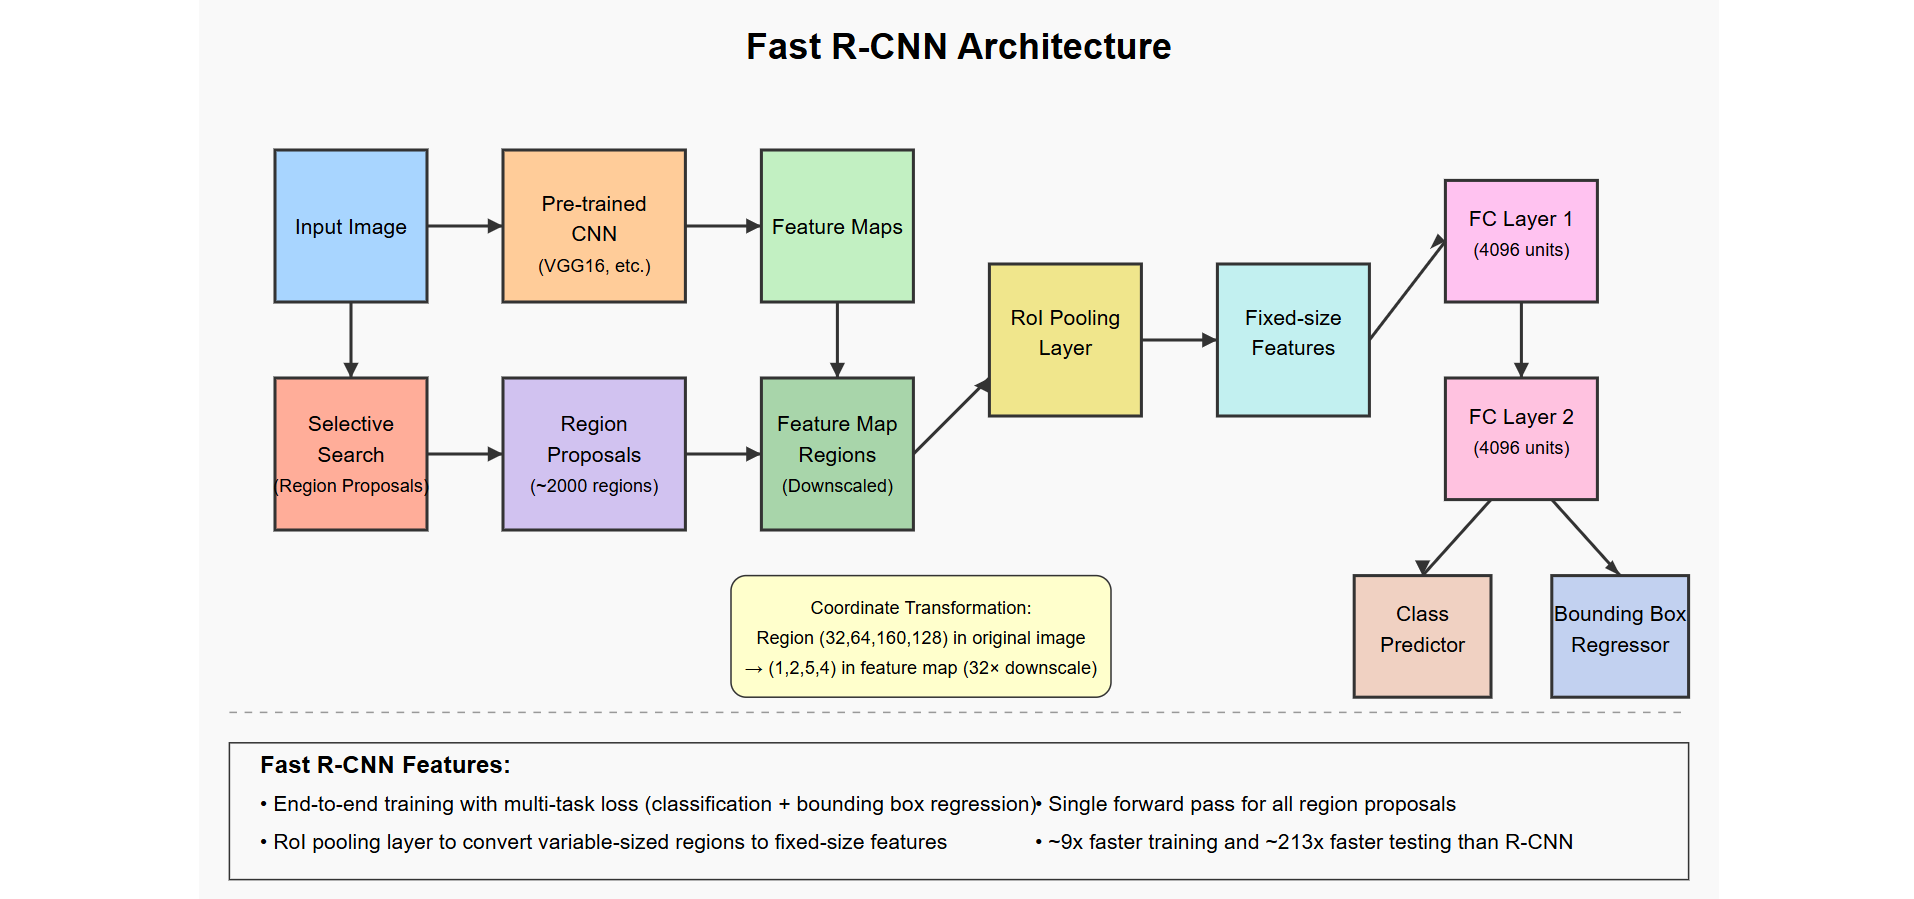

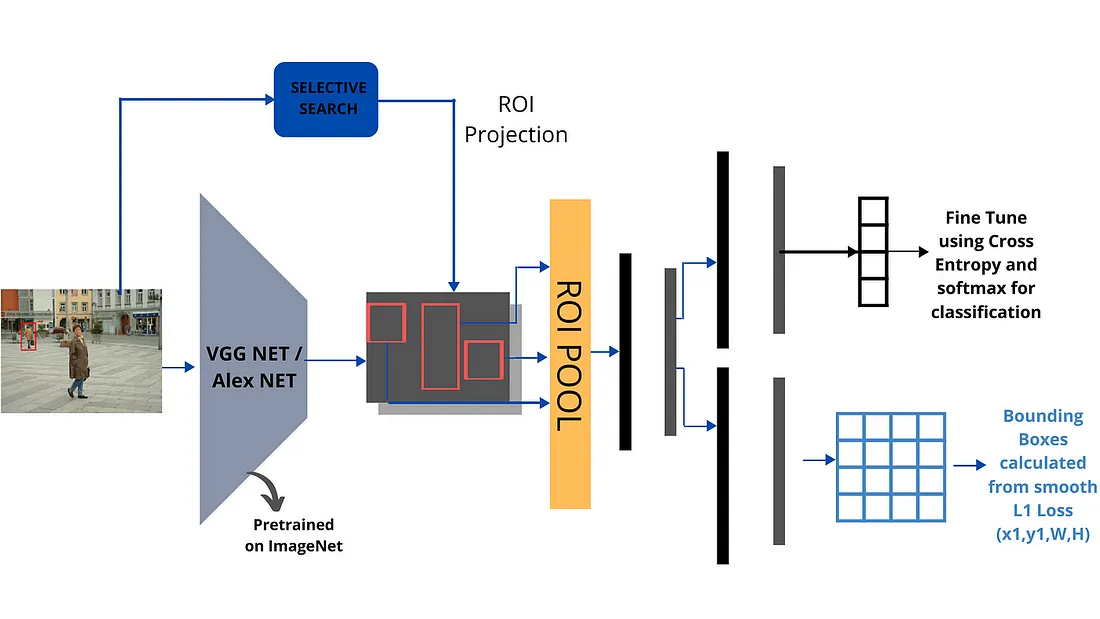

# Steps in Detailed way

###  1.  Pass the image through a pretrained model to extract features prior to the flattening layer; let's call them output feature maps

###  2.  Extract region proposals corresponding to the image.

###  3. Extract the feature map area corresponding to the region proposals (note that when an image is passed through a VGG16 architecture, the image is downscaled by 32 at the output, as five pooling operations are performed. Thus, if a region exists with a bounding box of (32, 64, 160, 128) in the original image, the feature map corresponding to the bounding box of (1, 22, 5, 4) wouldcorrespond to the exact same region).

###  4. Pass the feature maps corresponding to the region proposals through the region of Interest (RoI) pooling layer one at a time so that all the feature maps of region proposals have a similar shape.
### This is a replacement for the warping that was executed in the R-CNN technique.

###  5. Pass the RoI pooling layer output value through a fully connected layer.

###  6. Train the model to predict the class and offsets corresponding to each region proposal.


##### Note:

The big difference between R-CNN and Fast R-CNN is that, in R-CNN, we pass
the crops(resized region proposals) through the pre-trained model one at a time, while in Fast R-CNN, we crop the feature map (which is obtained by passing the whole image through a pre-trained model) corresponding to each region proposal, thereby avoiding the need to pass each resized region proposal through the pre-trained model.

In [1]:
%pip install -q --upgrade kaggle selectivesearch torch_snippets
from torch_snippets import *
import selectivesearch
import torch

# Authenticate Kaggle API
from google.colab import files
files.upload()  # Upload your kaggle.json

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset WITHOUT version flag
!kaggle datasets download -d sixhky/open-images-bus-trucks

# Verify download and unzip
!ls -lh *.zip
!unzip -qq open-images-bus-trucks.zip

# Import remaining components
from torchvision import transforms, models, datasets
from torchvision.ops import nms

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.7/220.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/sixhky/open-images-bus-trucks
License(s): unknown
-rw-r--r-- 1 root root 367M May 28  2020 open-images-bus-trucks.zip
Using device: cuda


In [2]:
IMAGE_ROOT = 'images/images'
DF_RAW = pd.read_csv('df.csv')
print(DF_RAW.head())

            ImageID  Source LabelName  Confidence      XMin      XMax  \
0  0000599864fd15b3  xclick       Bus           1  0.343750  0.908750   
1  00006bdb1eb5cd74  xclick     Truck           1  0.276667  0.697500   
2  00006bdb1eb5cd74  xclick     Truck           1  0.702500  0.999167   
3  00010bf498b64bab  xclick       Bus           1  0.156250  0.371250   
4  00013f14dd4e168f  xclick       Bus           1  0.287500  0.999375   

       YMin      YMax  IsOccluded  IsTruncated  ...  IsDepiction  IsInside  \
0  0.156162  0.650047           1            0  ...            0         0   
1  0.141604  0.437343           1            0  ...            0         0   
2  0.204261  0.409774           1            1  ...            0         0   
3  0.269188  0.705228           0            0  ...            0         0   
4  0.194184  0.999062           0            1  ...            0         0   

   XClick1X  XClick2X  XClick3X  XClick4X  XClick1Y  XClick2Y  XClick3Y  \
0  0.421875  0.34

In [3]:
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch_snippets import *
import cv2

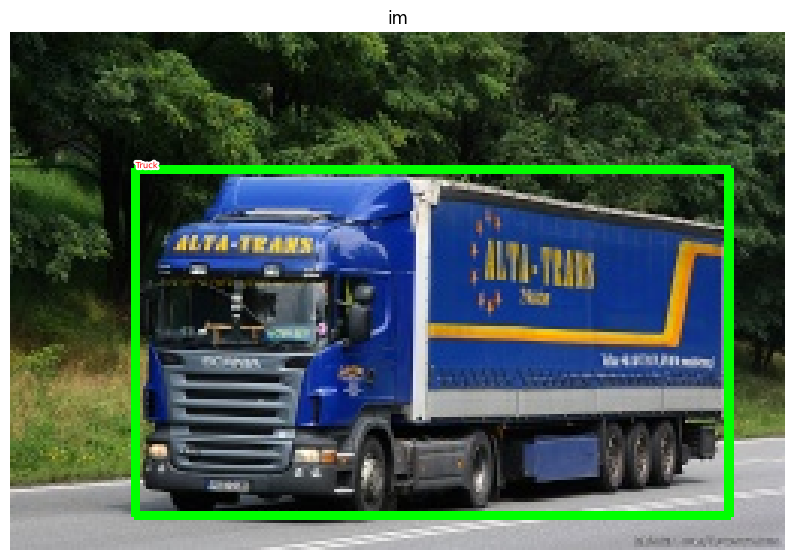

In [4]:
class OpenImages(Dataset):
    def __init__(self, df, image_folder=IMAGE_ROOT):
        self.root = image_folder
        self.df = df
        self.unique_images = df['ImageID'].unique()  # unique image IDs because an image can contain multiple objects and so multiple rows can correpond to the same ImageID value.
    def __len__(self): return len(self.unique_images)
    def __getitem__(self, ix):
        image_id = self.unique_images[ix]
        image_path = f'{self.root}/{image_id}.jpg'
        image = cv2.imread(image_path, 1)[...,::-1] # conver BGR to RGB
        h, w, _ = image.shape
        df = self.df.copy()
        df = df[df['ImageID'] == image_id]
        boxes = df['XMin,YMin,XMax,YMax'.split(',')].values
        boxes = (boxes * np.array([w,h,w,h])).astype(np.uint16).tolist()
        classes = df['LabelName'].values.tolist()
        return image, boxes, classes, image_path
ds = OpenImages(df=DF_RAW)
im, bbs, clss, _ = ds[9]
show(im, bbs=bbs, texts=clss, sz=10)

In [5]:
def extract_candidates(img):
    img_lbl, regions = selectivesearch.selective_search(img, scale=200, min_size=100)
    img_area = np.prod(img.shape[:2])
    candidates = []
    for r in regions:
        if r['rect'] in candidates: continue
        if r['size'] < (0.05*img_area): continue
        if r['size'] > (1*img_area): continue
        x, y, w, h = r['rect']
        candidates.append(list(r['rect']))
    return candidates
def extract_iou(boxA, boxB, epsilon=1e-5):
    x1 = max(boxA[0], boxB[0])
    y1 = max(boxA[1], boxB[1])
    x2 = min(boxA[2], boxB[2])
    y2 = min(boxA[3], boxB[3])
    width = (x2 - x1)
    height = (y2 - y1)
    if (width<0) or (height <0):
        return 0.0
    area_overlap = width * height
    area_a = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    area_b = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    area_combined = area_a + area_b - area_overlap
    iou = area_overlap / (area_combined+epsilon)
    return iou

In [ ]:
FPATHS, GTBBS, CLSS, DELTAS, ROIS, IOUS = [], [], [], [], [], []
# FPATHS --> List of image paths
# GTBBS --> List of ground truth bounding boxes
# CLSS --> List of classes for each bounding box
# DELTAS --> List of the delta offset of a bounding box with region proposals
# ROIS --> List of region proposals
# IOUS --> List of IoU values for each region proposal with the ground truth bounding boxes
N = 500
for ix, (im, bbs, labels, fpath) in enumerate(ds):
    if(ix==N):
        break
    H, W, _ = im.shape
    candidates = extract_candidates(im)
    candidates = np.array([(x,y,x+w,y+h) for x,y,w,h in candidates])
    ious, rois, clss, deltas = [], [], [], []
    ious = np.array([[extract_iou(candidate, _bb_) for candidate in candidates] for _bb_ in bbs]).T
    for jx, candidate in enumerate(candidates):
        cx,cy,cX,cY = candidate
        candidate_ious = ious[jx]
        best_iou_at = np.argmax(candidate_ious)
        best_iou = candidate_ious[best_iou_at]
        best_bb = _x,_y,_X,_Y = bbs[best_iou_at]
        if best_iou > 0.3: clss.append(labels[best_iou_at])
        else : clss.append('background')
        delta = np.array([_x-cx, _y-cy, _X-cX, _Y-cY]) / np.array([W,H,W,H])
        deltas.append(delta)
        rois.append(candidate / np.array([W,H,W,H]))
    FPATHS.append(fpath)
    IOUS.append(ious)
    ROIS.append(rois)
    CLSS.append(clss)
    DELTAS.append(deltas)
    GTBBS.append(bbs)
FPATHS = [f'{IMAGE_ROOT}/{stem(f)}.jpg' for f in FPATHS]
FPATHS, GTBBS, CLSS, DELTAS, ROIS = [item for item in [FPATHS, GTBBS, CLSS, DELTAS, ROIS]]

In [7]:
targets = pd.DataFrame(flatten(CLSS), columns=['label'])
label2target = {l:t for t,l in enumerate(targets['label'].unique())}
target2label = {t:l for l,t in label2target.items()}
background_class = label2target['background']

In [8]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
def preprocess_image(img):
    img = torch.tensor(img).permute(2,0,1)
    img = normalize(img)
    return img.to(device).float()
def decode(_y):
    _, preds = _y.max(-1)
    return preds


In [9]:
class FRCNNDataset(Dataset):
    def __init__(self, fpaths, rois, labels, deltas, gtbbs): # returns images, labels, ground-truths, region proposals and delta corresponding to each region proposal
        self.fpaths = fpaths
        self.gtbbs = gtbbs
        self.rois = rois
        self.labels = labels
        self.deltas = deltas
    def __len__(self): return len(self.fpaths)
    def __getitem__(self, ix):
        fpath = str(self.fpaths[ix])
        image = cv2.imread(fpath, 1)[...,::-1]
        gtbbs = self.gtbbs[ix]
        rois = self.rois[ix]
        labels = self.labels[ix]
        deltas = self.deltas[ix]
        assert len(rois) == len(labels) == len(deltas), f'{len(rois)}, {len(labels)}, {len(deltas)}'
        return image, rois, labels, deltas, gtbbs, fpath

    def collate_fn(self, batch):
        input, rois, rixs, labels, deltas = [], [], [], [], []
        for ix in range(len(batch)):
            image, image_rois, image_labels, image_deltas, image_gt_bbs, image_fpath = batch[ix]
            image = cv2.resize(image, (224,224))
            input.append(preprocess_image(image/255.)[None])
            rois.extend(image_rois)
            rixs.extend([ix]*len(image_rois))
            labels.extend([label2target[c] for c in image_labels])
            deltas.extend(image_deltas)
        input = torch.cat(input).to(device)
        rois = torch.Tensor(rois).float().to(device)
        rixs = torch.Tensor(rixs).float().to(device)
        labels = torch.Tensor(labels).long().to(device)
        deltas = torch.Tensor(deltas).float().to(device)
        return input, rois, rixs, labels, deltas

        # the rois matrix holds information regarding which RoI belongs to which image in the batch.
        # note that input contains multiple images, whereas rois is single list of boxes.
        # we wouldn't know how many RoIs belong to first image, how many belong to second image, and so on..

        #  This is where rixs comes into picture. It is a list of indexes. Each integer in the list associates the corresponding bounding box with the appropriate image;
        # for example, if rixs is [0,0,0,1,1,2,3,3,3], then we know the first three bounding boxes belong to the first image in the batch, and next two belong to the second image in the batch.



In [11]:
n_train = 9*len(FPATHS)//10   # 90% for training and 10% for testing
train_ds = FRCNNDataset(FPATHS[:n_train], ROIS[:n_train], CLSS[:n_train], DELTAS[:n_train], GTBBS[:n_train])
test_ds = FRCNNDataset(FPATHS[n_train:], ROIS[n_train:], CLSS[n_train:], DELTAS[n_train:], GTBBS[n_train:])

from torch.utils.data import TensorDataset, DataLoader
train_loader = DataLoader(train_ds, batch_size=2, collate_fn=train_ds.collate_fn, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=2, collate_fn=test_ds.collate_fn, drop_last=True)

In [12]:
from torchvision.ops import RoIPool
class FRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        rawnet = torchvision.models.vgg16_bn(pretrained=True) # loading the pretrained model and freeze the parameters
        for param in rawnet.features.parameters():
            param.requires_grad = True
        self.seq = nn.Sequential(*list(rawnet.features.children())[:-1]) # extracting features until the last layer
        # Specifying that RoIPool is to extract 7 x 7 output.
        # here spatial_scale is the factor by which proposals (which come from the original image) need to be shrunk so that every output has the same shape before passing through flatten layer.
        # images are 224 x 224 in size while feature map is 14 x 14 in size
        self.roipool = RoIPool(7, spatial_scale=14/224)
        feature_dim = 512*7*7
        self.cls_score = nn.Linear(feature_dim, len(label2target))
        self.bbox = nn.Sequential(
              nn.Linear(feature_dim, 512),
              nn.ReLU(),
              nn.Linear(512, 4),
              nn.Tanh(),
            )
        self.cel = nn.CrossEntropyLoss()
        self.sl1 = nn.L1Loss()
    def forward(self, input, rois, ridx):
        res = input
        res = self.seq(res)
        rois = torch.cat([ridx.unsqueeze(-1), rois*224], dim=-1)
        res = self.roipool(res, rois)
        feat = res.view(len(res), -1)
        cls_score = self.cls_score(feat)
        bbox = self.bbox(feat) # .view(-1, len(label2target), 4)
        return cls_score, bbox
    def calc_loss(self, probs, _deltas, labels, deltas):
        detection_loss = self.cel(probs, labels)
        ixs, = torch.where(labels != background_class)
        _deltas = _deltas[ixs]
        deltas = deltas[ixs]
        self.lmb = 10.0
        if len(ixs) > 0:
            regression_loss = self.sl1(_deltas, deltas)
            return detection_loss + self.lmb * regression_loss, detection_loss.detach(), regression_loss.detach()
        else:
            regression_loss = 0
            return detection_loss + self.lmb * regression_loss, detection_loss.detach(), regression_loss


In [13]:
def train_batch(inputs, model, optimizer, criterion):
    input, rois, rixs, clss, deltas = inputs
    model.train()
    optimizer.zero_grad()
    _clss, _deltas = model(input, rois, rixs)
    loss, loc_loss, regr_loss = criterion(_clss, _deltas, clss, deltas)
    accs = clss == decode(_clss)
    loss.backward()
    optimizer.step()
    return loss.detach(), loc_loss, regr_loss, accs.cpu().numpy()
def validate_batch(inputs, model, criterion):
    input, rois, rixs, clss, deltas = inputs
    with torch.no_grad():
        model.eval()
        _clss,_deltas = model(input, rois, rixs)
        loss, loc_loss, regr_loss = criterion(_clss, _deltas, clss, deltas)
        _clss = decode(_clss)
        accs = clss == _clss
    return _clss, _deltas, loss.detach(), loc_loss, regr_loss, accs.cpu().numpy()

In [14]:
import torchvision

Epoch 1/5
Train Loss: 1.9652 | Val Loss: 1.5630
Train Acc: 0.6527 | Val Acc: 0.7428
--------------------------------------------------
Epoch 2/5
Train Loss: 1.4440 | Val Loss: 1.4750
Train Acc: 0.7575 | Val Acc: 0.7585
--------------------------------------------------
Epoch 3/5
Train Loss: 1.1520 | Val Loss: 1.4750
Train Acc: 0.8125 | Val Acc: 0.7536
--------------------------------------------------
Epoch 4/5
Train Loss: 0.9852 | Val Loss: 1.3980
Train Acc: 0.8508 | Val Acc: 0.7591
--------------------------------------------------
Epoch 5/5
Train Loss: 0.8633 | Val Loss: 1.3896
Train Acc: 0.8763 | Val Acc: 0.7713
--------------------------------------------------


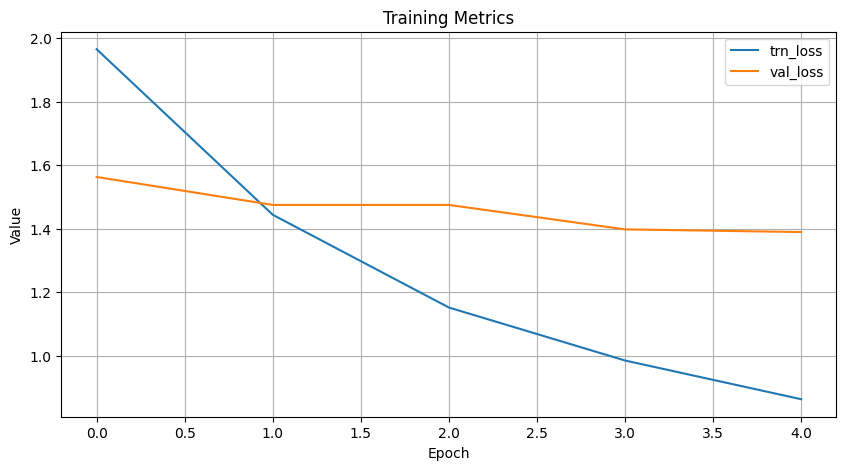

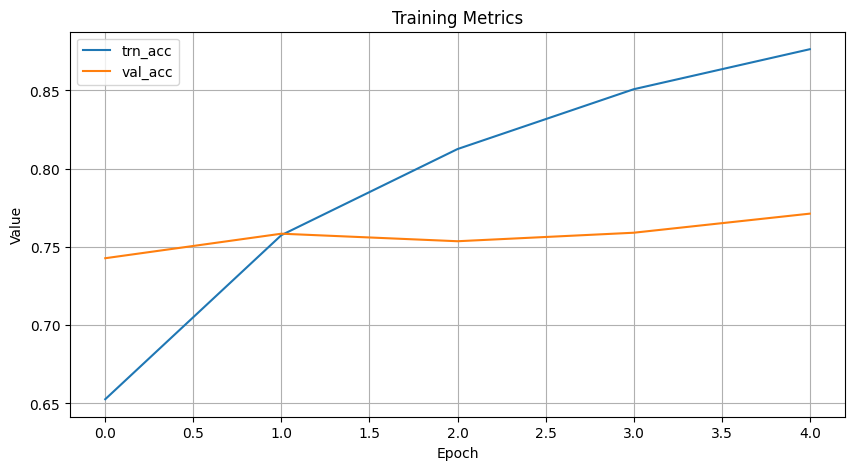

In [24]:
frcnn = FRCNN().to(device)
criterion = frcnn.calc_loss
optimizer = optim.SGD(frcnn.parameters(), lr=1e-3)

import matplotlib.pyplot as plt
n_epochs = 5

# Initialize metric tracking
history = {
    'trn_loss': [], 'trn_loc_loss': [], 'trn_regr_loss': [], 'trn_acc': [],
    'val_loss': [], 'val_loc_loss': [], 'val_regr_loss': [], 'val_acc': []
}

class MetricLogger:
    def __init__(self):
        self.reset()

    def reset(self):
        self.loss = 0.0
        self.loc_loss = 0.0
        self.regr_loss = 0.0
        self.acc = 0.0
        self.total = 0

    def update(self, loss, loc_loss, regr_loss, acc, batch_size):
        self.loss += loss * batch_size
        self.loc_loss += loc_loss * batch_size
        self.regr_loss += regr_loss * batch_size
        self.acc += acc * batch_size
        self.total += batch_size

    def get_avg(self):
        return {
            'loss': self.loss / self.total,
            'loc_loss': self.loc_loss / self.total,
            'regr_loss': self.regr_loss / self.total,
            'acc': self.acc / self.total
        }

for epoch in range(n_epochs):
    # Training phase
    train_logger = MetricLogger()
    frcnn.train()
    for inputs in train_loader:
        loss, loc_loss, regr_loss, accs = train_batch(inputs, frcnn, optimizer, criterion)
        batch_size = inputs[0].size(0)
        train_logger.update(loss.item(), loc_loss, regr_loss, accs.mean(), batch_size)

    # Record training metrics
    train_metrics = train_logger.get_avg()
    history['trn_loss'].append(train_metrics['loss'])
    history['trn_loc_loss'].append(train_metrics['loc_loss'])
    history['trn_regr_loss'].append(train_metrics['regr_loss'])
    history['trn_acc'].append(train_metrics['acc'])

    # Validation phase
    val_logger = MetricLogger()
    frcnn.eval()
    with torch.no_grad():
        for inputs in test_loader:
            _clss, _deltas, loss, loc_loss, regr_loss, accs = validate_batch(inputs, frcnn, criterion)
            batch_size = inputs[0].size(0)
            val_logger.update(loss.item(), loc_loss, regr_loss, accs.mean(), batch_size)

    # Record validation metrics
    val_metrics = val_logger.get_avg()
    history['val_loss'].append(val_metrics['loss'])
    history['val_loc_loss'].append(val_metrics['loc_loss'])
    history['val_regr_loss'].append(val_metrics['regr_loss'])
    history['val_acc'].append(val_metrics['acc'])

    # Print epoch summary
    print(f'Epoch {epoch+1}/{n_epochs}')
    print(f'Train Loss: {train_metrics["loss"]:.4f} | Val Loss: {val_metrics["loss"]:.4f}')
    print(f'Train Acc: {train_metrics["acc"]:.4f} | Val Acc: {val_metrics["acc"]:.4f}')
    print('-'*50)

# Plotting function
def plot_metrics(history, metrics):
    plt.figure(figsize=(10, 5))
    for metric in metrics:
        if metric in history:
            plt.plot(history[metric], label=metric)
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title('Training Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot training and validation losses
plot_metrics(history, ['trn_loss', 'val_loss'])
plot_metrics(history, ['trn_acc', 'val_acc'])


In [25]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.patches as mpatches
from torchvision.ops import nms
from PIL import Image
def test_predictions(filename):
    img = cv2.resize(np.array(Image.open(filename)), (224,224))
    candidates = extract_candidates(img)
    candidates = [(x,y,x+w,y+h) for x,y,w,h in candidates]
    input = preprocess_image(img/255.)[None]
    rois = [[x/224,y/224,X/224,Y/224] for x,y,X,Y in candidates]
    rixs = np.array([0]*len(rois))  # as all the proposals belong to the same image rixs will be list of zeros (as many as no. of proposals)
    rois, rixs = [torch.Tensor(item).to(device) for item in [rois, rixs]]
    with torch.no_grad():
        frcnn.eval()
        probs, deltas = frcnn(input, rois, rixs)
        confs, clss = torch.max(probs, -1)
    candidates = np.array(candidates)
    confs, clss, probs, deltas = [tensor.detach().cpu().numpy() for tensor in [confs, clss, probs, deltas]]

    # filtering out background class
    ixs = clss!=background_class
    confs, clss, probs, deltas, candidates = [tensor[ixs] for tensor in [confs, clss, probs, deltas, candidates]]
    bbs = candidates + deltas

    # removing near duplicate bounding boxes with nms function, and get indices of those proposals in which the higly confident models are objects.
    ixs = nms(torch.tensor(bbs.astype(np.float32)), torch.tensor(confs), 0.05)
    confs, clss, probs, deltas, candidates, bbs = [tensor[ixs] for tensor in [confs, clss, probs, deltas, candidates, bbs]]
    if len(ixs) == 1:
        confs, clss, probs, deltas, candidates, bbs = [tensor[None] for tensor in [confs, clss, probs, deltas, candidates, bbs]]

    bbs = bbs.astype(np.uint16)
    _, ax = plt.subplots(1, 2, figsize=(20,10))
    show(img, ax=ax[0])
    ax[0].grid(False)
    ax[0].set_title(filename.split('/')[-1])
    if len(confs) == 0:
        ax[1].imshow(img)
        ax[1].set_title('No objects')
        plt.show()
        return
    else:
        show(img, bbs=bbs.tolist(), texts=[target2label[c] for c in clss.tolist()], ax=ax[1])
        plt.show()

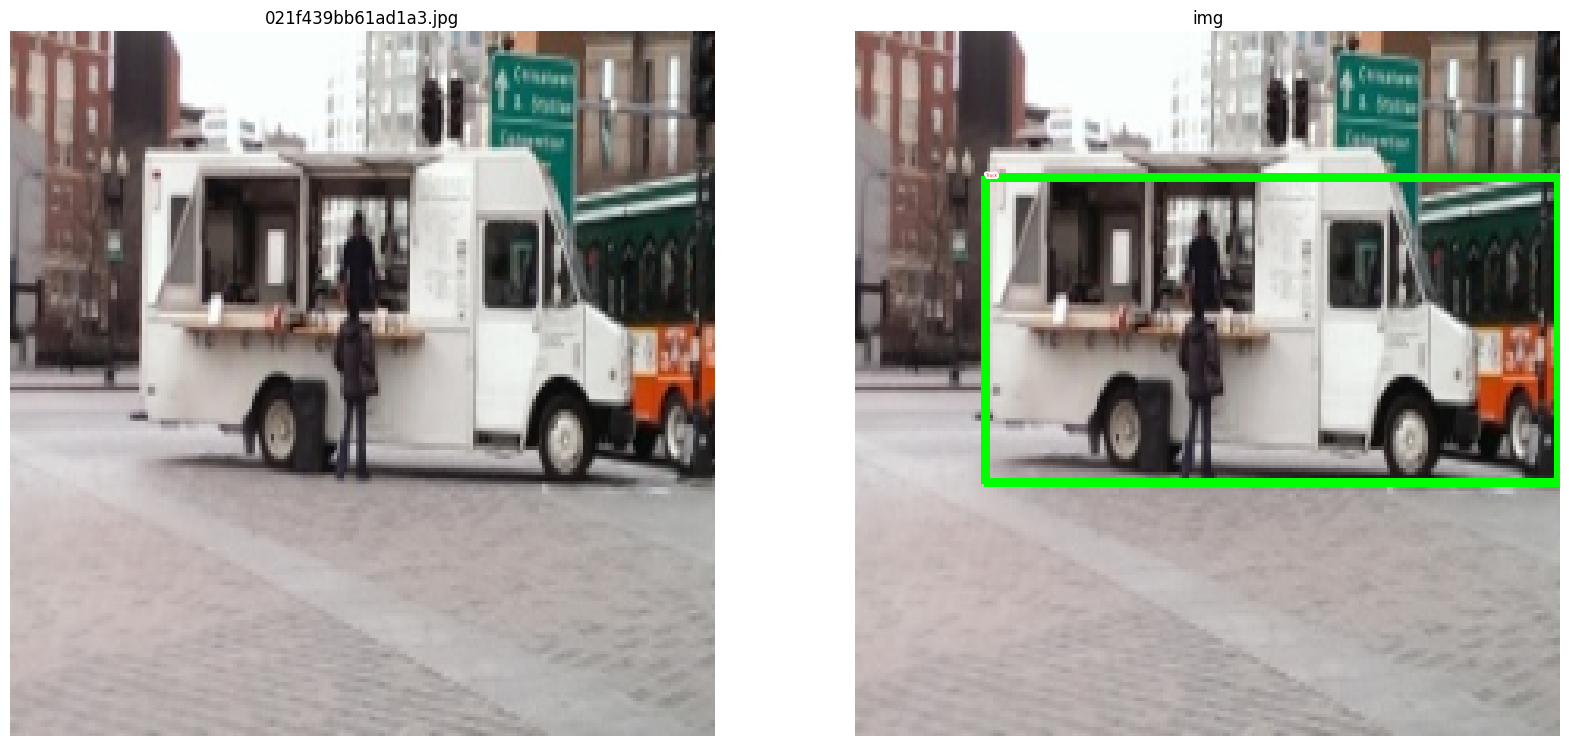

In [26]:
test_predictions(test_ds[29][-1])

### The preceding code executes in ~1.5 seconds. This is primarily because we are still using two different models , one to generate region proposals and another to make predictions of class and corrections. We will learn about having single model to make predictions so that inference is quick in a real time scenarios.